In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [35]:
# Dados de treino: duas frases simples
# Cada palavra é mapeada para um índice único
data = {"I love AI": [0, 1, 2], "AI is great": [2, 3, 4]}
vocab_size = 5  # Número total de palavras únicas

In [36]:
# Modelo de embedding
class WordEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(WordEmbeddingModel, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
    
    def forward(self, inputs):
        return self.embeddings(inputs)

In [37]:
# Função para treinar modelo de embedding
def train_embedding_model(embedding_dim, epochs=100):
    """
    Treina um modelo de embedding com a dimensão especificada.
    :param embedding_dim: Dimensão do embedding (ex: 2D ou 4D)
    :param epochs: Número de épocas de treinamento
    :return: Modelo treinado
    """
    optimizer = optim.SGD(embedding_dim.parameters(), lr=0.1)
    loss_fn = nn.MSELoss()
    
    inputs = torch.tensor([data["I love AI"], data["AI is great"]])
    targets = torch.randn_like(embedding_dim(inputs))  # Alvos aleatórios para simulação
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = embedding_dim(inputs)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()
    
    return embedding_dim

In [38]:
model_2d = WordEmbeddingModel(vocab_size, 2)
initial_embeddings_2d = model_2d.embeddings.weight.detach().numpy()

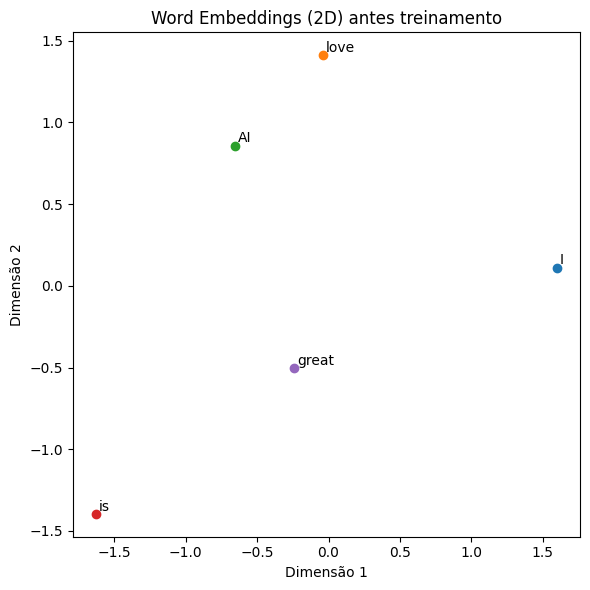

In [39]:
# Antes do treinamento
plt.figure(figsize=(6, 6))
for i, word in enumerate(words):
    plt.scatter(initial_embeddings_2d[i, 0], initial_embeddings_2d[i, 1])
    plt.text(initial_embeddings_2d[i, 0] + 0.02, initial_embeddings_2d[i, 1] + 0.02, word)
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.title("Word Embeddings (2D) antes treinamento")
# plt.grid()
plt.tight_layout()
plt.show()

In [40]:
initial_embeddings_2d

array([[ 1.5980384 ,  0.11148621],
       [-0.0391967 ,  1.4111539 ],
       [-0.655611  ,  0.8576057 ],
       [-1.6270243 , -1.3951387 ],
       [-0.23872417, -0.5049904 ]], dtype=float32)

In [41]:
train_embedding_model(model_2d)
final_embeddings_2d = model_2d.embeddings.weight.detach().numpy()

In [42]:
final_embeddings_2d

array([[-1.7165649 , -0.73733664],
       [-0.11592614,  0.5407043 ],
       [-0.69911444, -0.27715713],
       [ 0.14218695,  0.26346615],
       [-0.6877214 , -0.8311828 ]], dtype=float32)

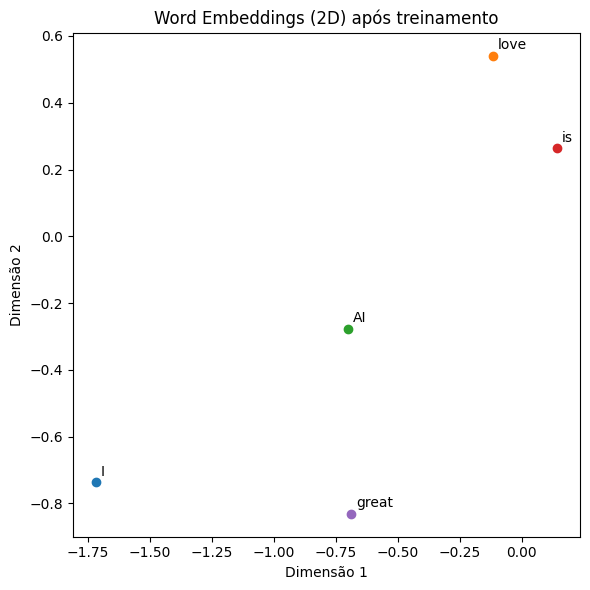

In [43]:
plt.figure(figsize=(6, 6))
for i, word in enumerate(words):
    plt.scatter(final_embeddings_2d[i, 0], final_embeddings_2d[i, 1])
    plt.text(final_embeddings_2d[i, 0] + 0.02, final_embeddings_2d[i, 1] + 0.02, word)
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.title("Word Embeddings (2D) após treinamento")
# plt.grid()
plt.tight_layout()
plt.show()